In [1]:
# Standard library
import kagglehub
import os
import gc
import json
import time
import warnings
import random
from pathlib import Path

# Numerical computing and data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import Markdown, display

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report, f1_score
from sklearn.model_selection import train_test_split


# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import datasets, models, transforms
from torchvision.models import ResNet50_Weights, vgg16, VGG16_Weights
from collections import Counter
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# UMAP
import umap
from tqdm import tqdm

# Suppress warnings
warnings.filterwarnings('ignore')









# Table of Contents
[Table of Contents](#scrollTo=UlhVacMyy6j3)

>[Autoencoder](#scrollTo=bBuOk9iv9yQ6)

>>[Performance Monitoring](#scrollTo=sGSQj2_Gu8sw)
---

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# reproducibility
SEED = 1187
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
adults_cache = Path("/content/drive/MyDrive/fer-project/fer2013_processed/fer2013_adults.pt")

# Load JSON regardless — needed for label_strs and genders even on cache hit
with open("/content/drive/MyDrive/fer-project/fer2013_processed/classified_files.json") as f:
    loaded_data = json.load(f)

records    = loaded_data["adult_records"]
label_strs = [r["emotion"] for r in records]
genders    = [r["gender"]  for r in records]
label_names  = sorted(set(label_strs))
label_to_idx = {l: i for i, l in enumerate(label_names)}

if adults_cache.exists():
    print("Loading from cache...")
    d = torch.load(adults_cache, weights_only=False)
    X = d["X"].numpy()
    X_CNN = d["X_CNN"].numpy()
    y = d["y"].numpy()
    paths = d["paths"]
    print(f"Loaded from cache: {len(paths)} images")
else:
    print("Cache not found — loading from Drive (this will take ~30-60 min)...")
    paths = [Path(r["drive_path"]) for r in records]

    base_transform = transforms.Compose([
        transforms.Resize((48, 48)),
        transforms.ToTensor(),
    ])
    cnn_transform = transforms.Normalize(mean=[0.5], std=[0.5])

    X_tensors = torch.stack([base_transform(Image.open(p).convert("L")) for p in tqdm(paths)])
    X  = X_tensors.view(X_tensors.shape[0], -1)
    X_CNN     = torch.stack([cnn_transform(t) for t in X_tensors])
    y         = torch.tensor([label_to_idx[e] for e in label_strs], dtype=torch.long)

    # Save cache to Drive — future runs will skip all of the above
    torch.save({"X": X, "X_CNN": X_CNN, "y": y, "paths": paths}, adults_cache)
    print(f"Cache saved: {adults_cache}")

    X = X.numpy()
    X_CNN = X_CNN.numpy()
    y = y.numpy()

print(f"Adults-only subset loaded: {len(paths)} images (full dataset had ~35,887).")
print("Flattened data shape (X):", X.shape)
print("CNN data shape (X_CNN):", X_CNN.shape)
print("Labels:", label_names)

Loading from cache...
Loaded from cache: 25175 images
Adults-only subset loaded: 25175 images (full dataset had ~35,887).
Flattened data shape (X): (25175, 2304)
CNN data shape (X_CNN): (25175, 1, 48, 48)
Labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [5]:
df_images = pd.DataFrame({
    'filepath': [str(p) for p in paths],
    'label': label_strs,
    'label_idx': [label_to_idx[l] for l in label_strs]
})

unique_labels = df_images['label'].unique()

sampled_images_paths = []
for label in unique_labels:
    label_samples = df_images[df_images['label'] == label].sample(n=min(36, len(df_images[df_images['label'] == label])), random_state=42)
    sampled_images_paths.extend(label_samples.to_dict('records'))

print(f"Total unique labels: {len(unique_labels)}")
print(f"Total sampled images: {len(sampled_images_paths)}")


Total unique labels: 7
Total sampled images: 252


In [6]:
# Shared file-based split used by Autoencoder and VGG
# Derived from the cleaned adults-only paths loaded above
all_paths_str = [str(p) for p in paths]
shared_idx = np.arange(len(all_paths_str))
shared_idx_train, shared_idx_temp = train_test_split(
    shared_idx, test_size=0.20, stratify=y, random_state=42)
shared_idx_val, shared_idx_test = train_test_split(
    shared_idx_temp, test_size=0.5, stratify=y[shared_idx_temp], random_state=42)

shared_train_files = [all_paths_str[i] for i in shared_idx_train]
shared_train_labels = list(y[shared_idx_train].astype(int))
shared_train_labels_str = [label_strs[i] for i in shared_idx_train]

shared_val_files = [all_paths_str[i] for i in shared_idx_val]
shared_val_labels = list(y[shared_idx_val].astype(int))
shared_val_labels_str = [label_strs[i] for i in shared_idx_val]

shared_test_files = [all_paths_str[i] for i in shared_idx_test]
shared_test_labels = list(y[shared_idx_test].astype(int))
shared_test_labels_str = [label_strs[i] for i in shared_idx_test]

print(f"Shared file-based split (adults-only, {len(all_paths_str)} total):")
print(f"  Train: {len(shared_train_files)} | Val: {len(shared_val_files)} | Test: {len(shared_test_files)}")


Shared file-based split (adults-only, 25175 total):
  Train: 20140 | Val: 2517 | Test: 2518


# Autoencoder

The implementation below uses a two-stage transfer learning approach to address emotion classification. In Stage 1, we train a convolutional autoencoder in an unsupervised manner to learn compressed representations of facial images. The encoder consists of three convolutional layers with batch normalization that progressively downsample 48×48 grayscale images into a 128-dimensional latent space, while the decoder mirrors this architecture using transposed convolutions to reconstruct the original images. We trained this autoencoder for 25 epochs using MSE loss, allowing it to learn meaningful facial feature representations without relying on emotion labels. In Stage 2, we leverage these learned representations for emotion classification by freezing the pretrained encoder weights and attaching a lightweight classification head (dropout layer and two fully connected layers). This transfer learning strategy offers several advantages: (1) the encoder learns robust, generalizable features through reconstruction rather than overfitting to emotion labels, (2) freezing the encoder during classification training prevents catastrophic forgetting of these learned representations, and (3) the approach can be particularly effective when labeled data is limited or noisy, as the autoencoder leverages all available images regardless of label quality. We applied aggressive data augmentation (rotation, horizontal flips, affine transforms, color jitter) during both training stages to improve generalization. The final model was evaluated on a held-out test set.


In [7]:
# Custom dataset class for on-the-fly loading
class FER2013Dataset(Dataset):
    """Custom dataset that loads images on-the-fly and applies transforms"""
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image as PIL
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('L')
        label = self.labels[idx]

        # Apply transforms (includes augmentation, ToTensor, Normalize)
        if self.transform:
            image = self.transform(image)

        return image, label


In [8]:
# Autoencoder DataLoaders (48x48 grayscale, using the shared adults-only split)
ae_train_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.RandomRotation(degrees=15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

ae_val_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

BATCH_SIZE = 64
ae_train_dataset = FER2013Dataset(shared_train_files, shared_train_labels, transform=ae_train_transform)
ae_val_dataset   = FER2013Dataset(shared_val_files,   shared_val_labels,   transform=ae_val_transform)
ae_test_dataset  = FER2013Dataset(shared_test_files,  shared_test_labels,  transform=ae_val_transform)

ae_train_loader = DataLoader(ae_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
ae_val_loader   = DataLoader(ae_val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
ae_test_loader  = DataLoader(ae_test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Autoencoder DataLoaders ready (batch size {BATCH_SIZE})")
print(f"  Train: {len(ae_train_dataset)} | Val: {len(ae_val_dataset)} | Test: {len(ae_test_dataset)}")


Autoencoder DataLoaders ready (batch size 64)
  Train: 20140 | Val: 2517 | Test: 2518


In [ ]:

# Autoencoder architecture
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super(ConvAutoencoder, self).__init__()

        # ENCODER
        self.encoder = nn.Sequential(
            # Layer 1: 1 x 48 x 48 -> 32 x 24 x 24
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # Layer 2: 32 x 24 x 24 -> 64 x 12 x 12
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # Layer 3: 64 x 12 x 12 -> 128 x 6 x 6
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )

        # Bottleneck
        self.flatten = nn.Flatten()
        self.fc_encoder = nn.Linear(128 * 6 * 6, latent_dim)

        # DECODER
        self.fc_decoder = nn.Linear(latent_dim, 128 * 6 * 6)

        self.decoder = nn.Sequential(
            # 128 x 6 x 6 -> 64 x 12 x 12
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # 64 x 12 x 12 -> 32 x 24 x 24
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # 32 x 24 x 24 -> 1 x 48 x 48
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Tanh()
        )

        self.latent_dim = latent_dim

    def encode(self, x):
        # Extract latent features
        x = self.encoder(x)
        x = self.flatten(x)
        x = self.fc_encoder(x)
        return x

    def decode(self, z):
        # Reconstruct from latent features
        x = self.fc_decoder(z)
        x = x.view(-1, 128, 6, 6)
        x = self.decoder(x)
        return x

    def forward(self, x):
        # Full autoencoder pass
        z = self.encode(x)
        reconstruction = self.decode(z)
        return reconstruction, z


class EmotionClassifier(nn.Module):
    def __init__(self, autoencoder, num_classes=7, freeze_encoder=True):
        super(EmotionClassifier, self).__init__()

        # Use encoder from autoencoder
        self.encoder = autoencoder.encoder
        self.fc_encoder = autoencoder.fc_encoder
        self.flatten = autoencoder.flatten

        # Freeze encoder if specified
        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False
            for param in self.fc_encoder.parameters():
                param.requires_grad = False

        # Classification head
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(autoencoder.latent_dim, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Extract features
        x = self.encoder(x)
        x = self.flatten(x)
        features = self.fc_encoder(x)

        # Classify
        x = self.dropout(F.relu(self.fc1(features)))
        return self.fc2(x)


In [ ]:
# Training functions
def train_autoencoder_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    total_samples = 0

    for inputs, _ in train_loader:
        inputs = inputs.to(device)

        optimizer.zero_grad()
        reconstructions, _ = model(inputs)
        loss = criterion(reconstructions, inputs)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        total_samples += inputs.size(0)

    epoch_loss = running_loss / total_samples
    return epoch_loss


def evaluate_autoencoder(model, data_loader, criterion, device):
    # Evaluate autoencoder
    model.eval()
    running_loss = 0.0
    total_samples = 0

    with torch.inference_mode():
        for inputs, _ in data_loader:
            inputs = inputs.to(device)
            reconstructions, _ = model(inputs)
            loss = criterion(reconstructions, inputs)

            running_loss += loss.item() * inputs.size(0)
            total_samples += inputs.size(0)

    epoch_loss = running_loss / total_samples
    return epoch_loss


def train_classifier_epoch(model, train_loader, criterion, optimizer, device):
    # rain classifier for one epoch
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    return epoch_loss, epoch_acc


def evaluate_classifier(model, data_loader, criterion, device):
    # Evaluate classifier
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.inference_mode():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    return epoch_loss, epoch_acc

Stage 1: Training Autoencoder
Starting autoencoder training...
Epoch 1/25 - Train Loss: 0.124893 - Val Loss: 0.063938
Epoch 2/25 - Train Loss: 0.053969 - Val Loss: 0.048856
Epoch 3/25 - Train Loss: 0.044668 - Val Loss: 0.036315
Epoch 4/25 - Train Loss: 0.039749 - Val Loss: 0.032327
Epoch 5/25 - Train Loss: 0.037006 - Val Loss: 0.032387
Epoch 6/25 - Train Loss: 0.035317 - Val Loss: 0.031040
Epoch 7/25 - Train Loss: 0.033495 - Val Loss: 0.031916
Epoch 8/25 - Train Loss: 0.032482 - Val Loss: 0.029006
Epoch 9/25 - Train Loss: 0.031883 - Val Loss: 0.027003
Epoch 10/25 - Train Loss: 0.031548 - Val Loss: 0.026975
Epoch 11/25 - Train Loss: 0.031505 - Val Loss: 0.027066
Epoch 12/25 - Train Loss: 0.030409 - Val Loss: 0.027259
Epoch 13/25 - Train Loss: 0.030718 - Val Loss: 0.026850
Epoch 14/25 - Train Loss: 0.030563 - Val Loss: 0.027312
Epoch 15/25 - Train Loss: 0.029803 - Val Loss: 0.029784
Epoch 16/25 - Train Loss: 0.029687 - Val Loss: 0.025875
Epoch 17/25 - Train Loss: 0.029656 - Val Loss: 0.0

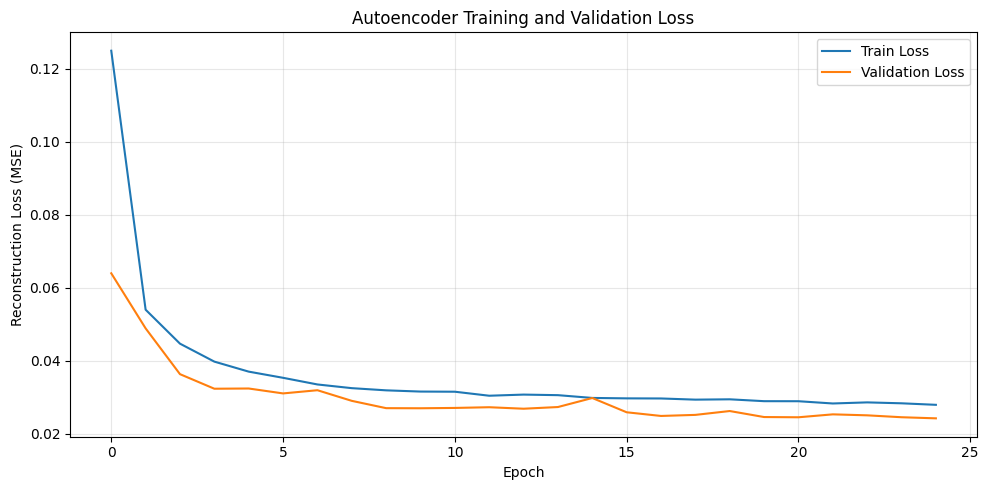

In [ ]:
# Training autoencoder

print("Stage 1: Training Autoencoder")


# Initialize autoencoder
autoencoder = ConvAutoencoder(latent_dim=128).to(device)
compiled_autoencoder = autoencoder

# Optimizer settings
criterion_ae = nn.MSELoss()
optimizer_ae = optim.Adam(compiled_autoencoder.parameters(), lr=0.001, weight_decay=1e-4)

# Train for 25 epochs
num_epochs = 25
history_ae = {
    'train_loss': [],
    'val_loss': []
}

print("Starting autoencoder training...")
for epoch in range(num_epochs):
    train_loss = train_autoencoder_epoch(
        compiled_autoencoder,
        ae_train_loader,
        criterion_ae,
        optimizer_ae,
        device
    )

    val_loss = evaluate_autoencoder(compiled_autoencoder, ae_val_loader, criterion_ae, device)

    history_ae['train_loss'].append(train_loss)
    history_ae['val_loss'].append(val_loss)

    print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.6f} - Val Loss: {val_loss:.6f}')

print("Autoencoder training complete!")

# Plot autoencoder training
plt.figure(figsize=(10, 5))
plt.plot(history_ae['train_loss'], label='Train Loss')
plt.plot(history_ae['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

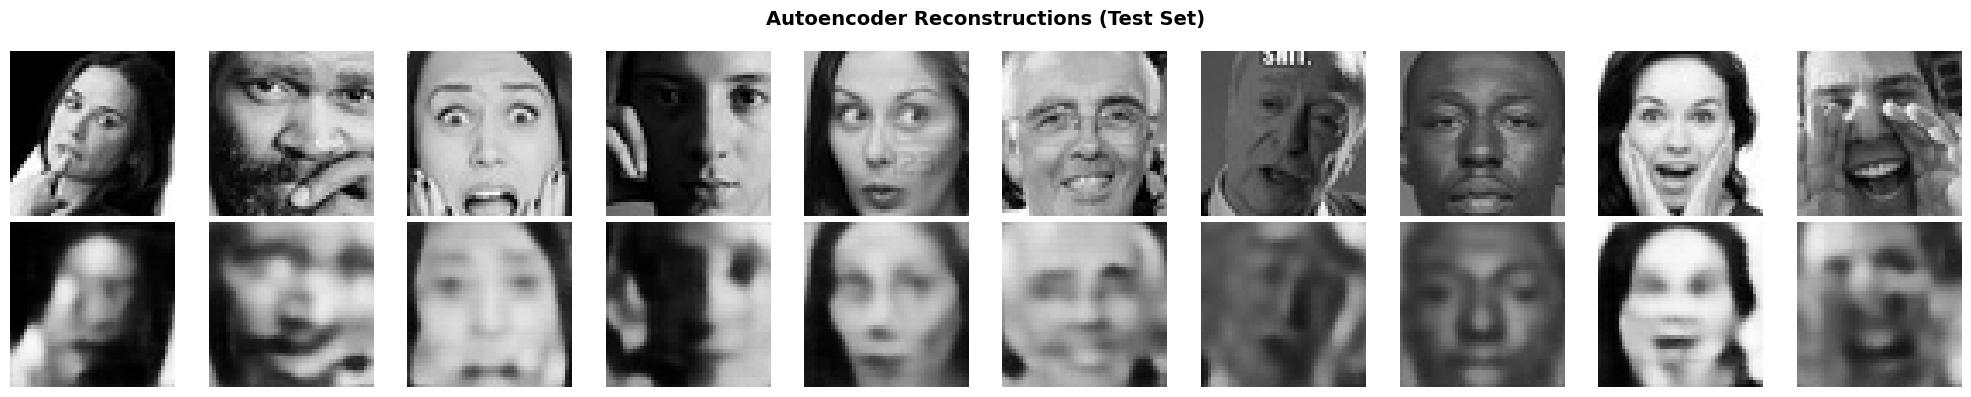

In [ ]:
# Visualize reconstructions

compiled_autoencoder.eval()
with torch.inference_mode():
    # Get a batch from test set
    sample_inputs, _ = next(iter(ae_test_loader))
    sample_inputs = sample_inputs[:10].to(device)

    reconstructions, _ = compiled_autoencoder(sample_inputs)


sample_inputs = sample_inputs.cpu()
reconstructions = reconstructions.cpu()

fig, axes = plt.subplots(2, 10, figsize=(20, 4))

for i in range(10):
    # Original
    img = sample_inputs[i].squeeze().numpy()
    img = (img * 0.5) + 0.5
    axes[0, i].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=12, fontweight='bold')

    # Reconstruction
    recon = reconstructions[i].squeeze().numpy()
    recon = (recon * 0.5) + 0.5
    axes[1, i].imshow(recon, cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Reconstructed', fontsize=12, fontweight='bold')

plt.suptitle('Autoencoder Reconstructions (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Train classifier
print("Stage 2: Training Emotion Classifer (Using Pretrained Encoder)")

# Create classifier with frozen encoder (feature extraction mode)
num_classes = len(label_names)
classifier = EmotionClassifier(
    compiled_autoencoder,
    num_classes=num_classes,
    freeze_encoder=True
).to(device)

compiled_classifier = torch.compile(classifier)

# Optimizer settings
criterion_clf = nn.CrossEntropyLoss()
optimizer_clf = optim.Adam(compiled_classifier.parameters(), lr=0.001, weight_decay=1e-4)

# Train for 25 epochs
history_clf = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print("Starting classifier training...")
for epoch in range(num_epochs):
    train_loss, train_acc = train_classifier_epoch(
        compiled_classifier,
        ae_train_loader,
        criterion_clf,
        optimizer_clf,
        device
    )

    val_loss, val_acc = evaluate_classifier(compiled_classifier, ae_val_loader, criterion_clf, device)

    history_clf['train_loss'].append(train_loss)
    history_clf['train_acc'].append(train_acc)
    history_clf['val_loss'].append(val_loss)
    history_clf['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

print("Classifier training complete!")


STAGE 2: TRAINING EMOTION CLASSIFIER (Using Pretrained Encoder)
Starting classifier training...
Epoch 1/25 - Train Loss: 1.7896, Train Acc: 0.2681 - Val Loss: 1.7269, Val Acc: 0.3023
Epoch 2/25 - Train Loss: 1.7453, Train Acc: 0.2923 - Val Loss: 1.6861, Val Acc: 0.3449
Epoch 3/25 - Train Loss: 1.7365, Train Acc: 0.3010 - Val Loss: 1.6675, Val Acc: 0.3445
Epoch 4/25 - Train Loss: 1.7232, Train Acc: 0.3059 - Val Loss: 1.6566, Val Acc: 0.3592
Epoch 5/25 - Train Loss: 1.7220, Train Acc: 0.3100 - Val Loss: 1.6459, Val Acc: 0.3603
Epoch 6/25 - Train Loss: 1.7126, Train Acc: 0.3129 - Val Loss: 1.6380, Val Acc: 0.3659
Epoch 7/25 - Train Loss: 1.7097, Train Acc: 0.3157 - Val Loss: 1.6305, Val Acc: 0.3719
Epoch 8/25 - Train Loss: 1.6975, Train Acc: 0.3275 - Val Loss: 1.6207, Val Acc: 0.3731
Epoch 9/25 - Train Loss: 1.6970, Train Acc: 0.3259 - Val Loss: 1.6095, Val Acc: 0.3798
Epoch 10/25 - Train Loss: 1.6902, Train Acc: 0.3250 - Val Loss: 1.6084, Val Acc: 0.3770
Epoch 11/25 - Train Loss: 1.6843

### Performance Monitoring
We track the loss/accuracy at every epoch. We evaluate the model using metrics such as accuracy, confusion matrix, and per-class F1 scores.

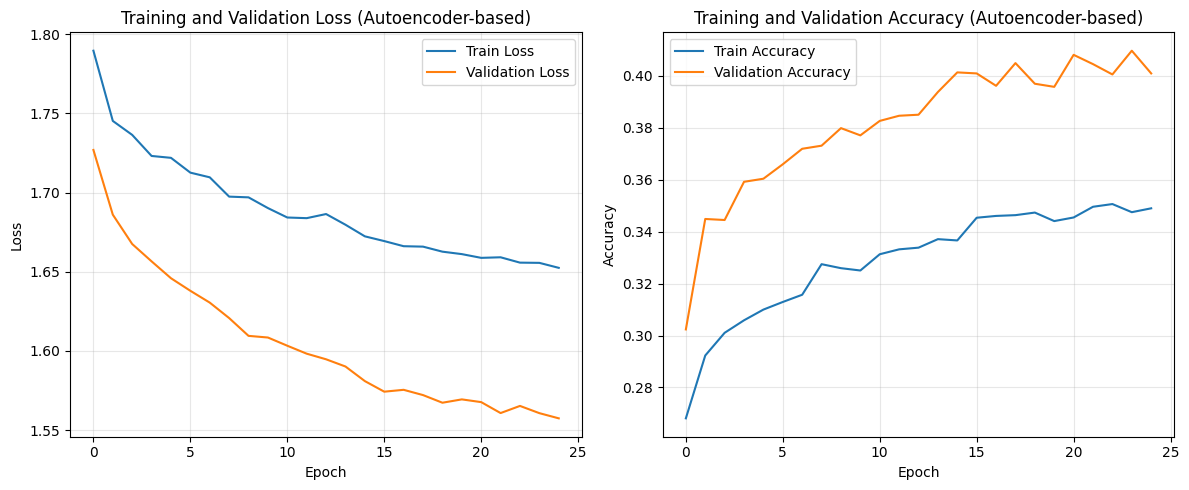

In [ ]:
# Plotting training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_clf['train_loss'], label='Train Loss')
plt.plot(history_clf['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (Autoencoder-based)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history_clf['train_acc'], label='Train Accuracy')
plt.plot(history_clf['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (Autoencoder-based)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


FINAL EVALUATION ON TEST SET

Classification Report:
              precision    recall  f1-score   support

       angry       0.34      0.21      0.26       365
     disgust       0.00      0.00      0.00        46
        fear       0.23      0.12      0.16       373
       happy       0.44      0.84      0.58       665
     neutral       0.38      0.32      0.35       444
         sad       0.37      0.28      0.32       405
    surprise       0.48      0.34      0.40       220

    accuracy                           0.40      2518
   macro avg       0.32      0.30      0.29      2518
weighted avg       0.37      0.40      0.36      2518



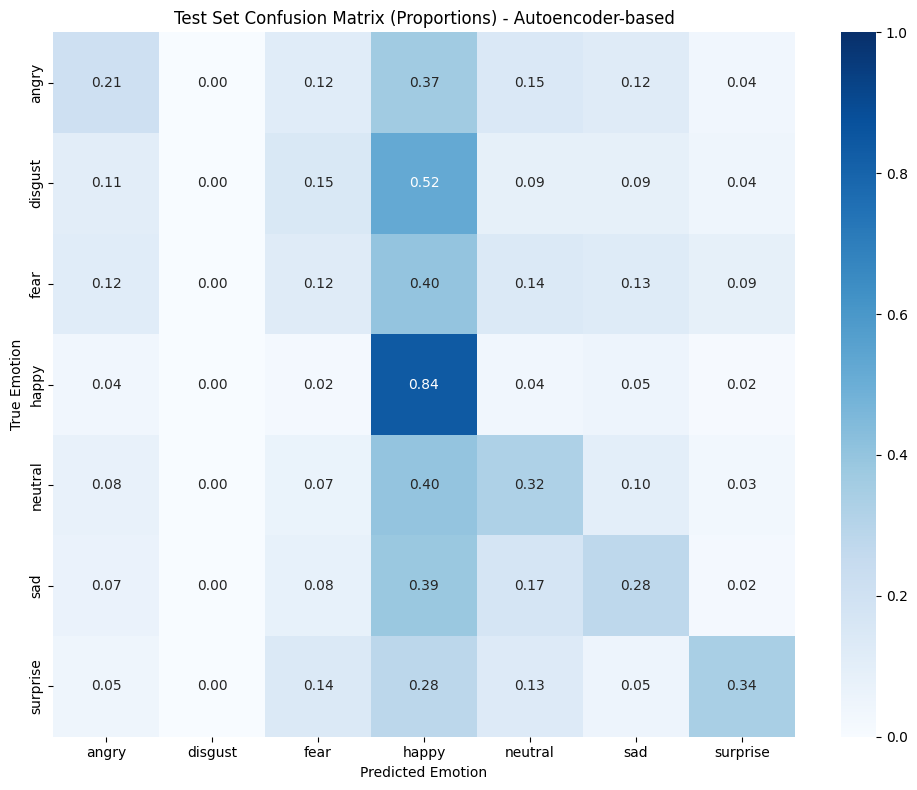


Overall Test Accuracy: 0.4007 (40.07%)

TRAINING AND EVALUATION COMPLETE!


In [ ]:
# Testing on test set

print("\n" + "="*80)
print("FINAL EVALUATION ON TEST SET")
print("="*80)

# Put model in evaluation mode
compiled_classifier.eval()

all_preds = []
all_targets = []

# Run inference without gradients
with torch.inference_mode():
    for inputs, labels in ae_test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = compiled_classifier(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

# Convert to arrays
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Print Classification Report
print("\nClassification Report:")
print(classification_report(all_targets, all_preds, target_names=label_names))

# Calculate confusion matrix
cm = confusion_matrix(all_targets, all_preds)

# Row-normalized confusion matrix
cm_prop = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_prop,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    vmin=0,
    vmax=1
)

plt.title("Test Set Confusion Matrix (Proportions) - Autoencoder-based")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.tight_layout()
plt.savefig("autoencoder_matrix.png")
plt.show()

# Calculate overall test accuracy
test_accuracy = (all_preds == all_targets).sum() / len(all_targets)
print(f"\nOverall Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print("\n" + "="*80)
print("TRAINING AND EVALUATION COMPLETE!")
print("="*80)
